# Sowing Success: How Machine Learning Helps Farmers Select the Best Crops

![Farmer in a field](../images/farmer_in_a_field.jpg)

Measuring essential soil metrics such as nitrogen, phosphorous, potassium levels, and pH value is an important aspect of assessing soil condition. However, it can be an expensive and time-consuming process, which can cause farmers to prioritize which metrics to measure based on their budget constraints.

Farmers have various options when it comes to deciding which crop to plant each season. Their primary objective is to maximize the yield of their crops, taking into account different factors. One crucial factor that affects crop growth is the condition of the soil in the field, which can be assessed by measuring basic elements such as nitrogen and potassium levels. Each crop has an ideal soil condition that ensures optimal growth and maximum yield.

A farmer reached out to you as a machine learning expert for assistance in selecting the best crop for his field. They've provided you with a dataset called `soil_measures.csv`, which contains:

- `"N"`: Nitrogen content ratio in the soil
- `"P"`: Phosphorous content ratio in the soil
- `"K"`: Potassium content ratio in the soil
- `"pH"` value of the soil
- `"crop"`: categorical values that contain various crops (target variable).

Each row in this dataset represents various measures of the soil in a particular field. Based on these measurements, the crop specified in the `"crop"` column is the optimal choice for that field.  

In this project, I am building multi-class classification models to predict the type of `"crop"` and identify the single most importance feature for predictive performance.

In [1]:
import pandas as pd
import warnings; warnings.filterwarnings('ignore')

# Load the dataset
crops = pd.read_csv("../data/soil_measures.csv")

In [2]:
# Dataset overview
print(f"Dataset shape: {crops.shape}")
print(f"\nClass distribution:")
print(crops['crop'].value_counts())
print(f"\nStatistical summary:")
print(crops.describe())

Dataset shape: (2200, 5)

Class distribution:
crop
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

Statistical summary:
                 N            P            K           ph
count  2200.000000  2200.000000  2200.000000  2200.000000
mean     50.551818    53.362727    48.149091     6.469480
std      36.917334    32.985883    50.647931     0.773938
min       0.000000     5.000000     5.000000     3.504752
25%      21.000000    28.000000    20.000000     5.971693
50%      37.000000    51.000000    32.000000     6.425045
75%      84.250000    68.000000    49.000000     6.923643
max     140.000000 

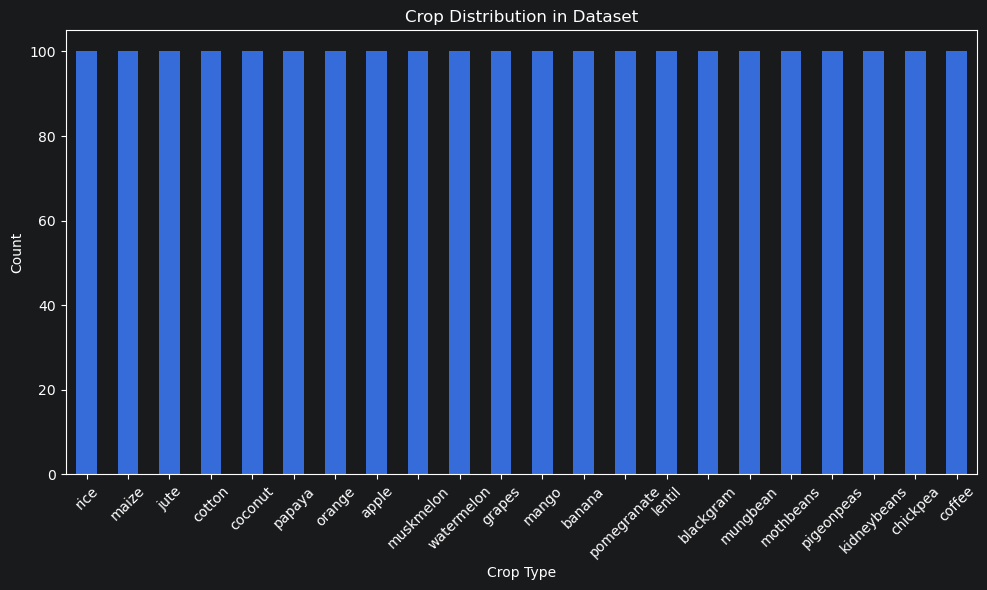

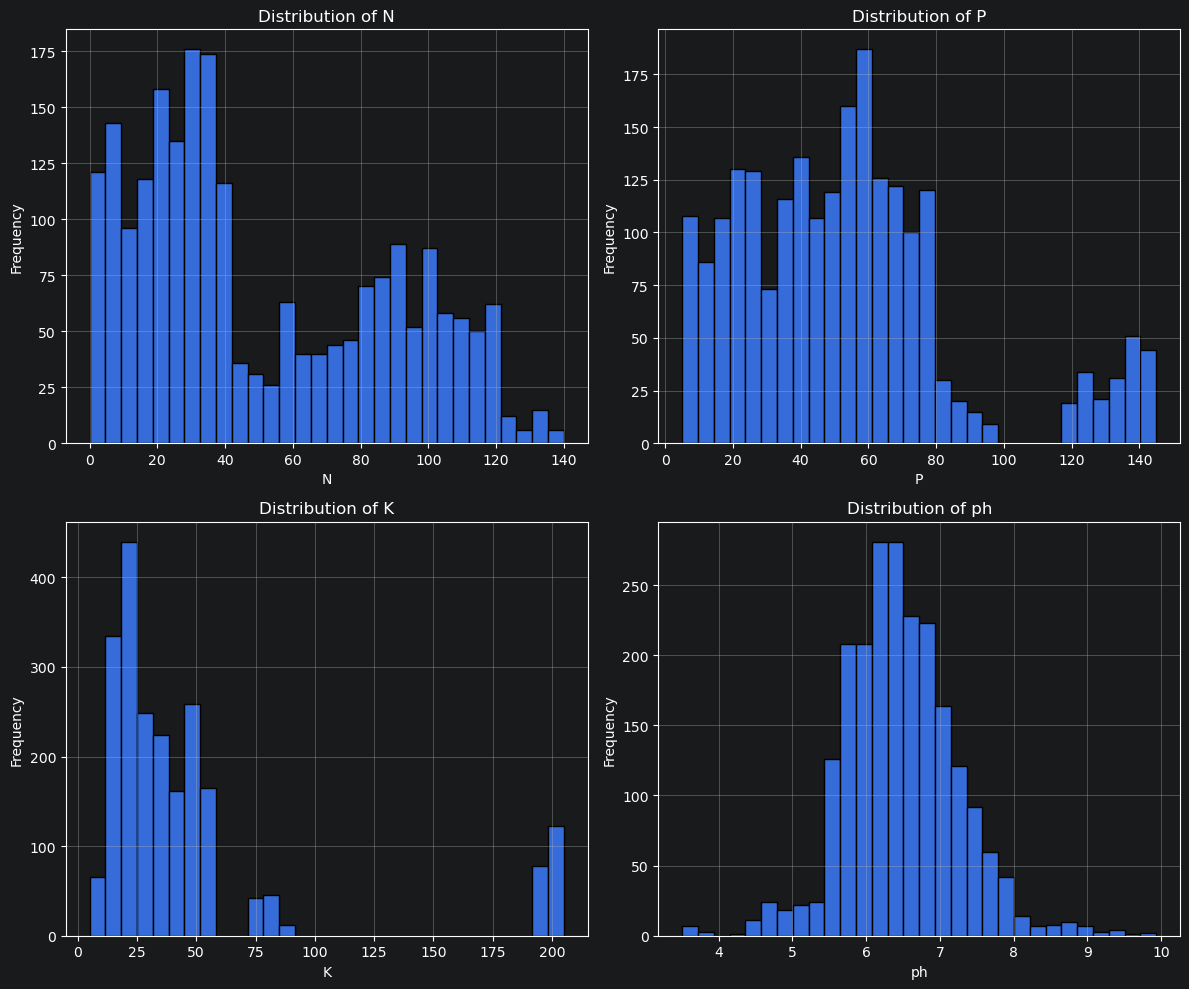

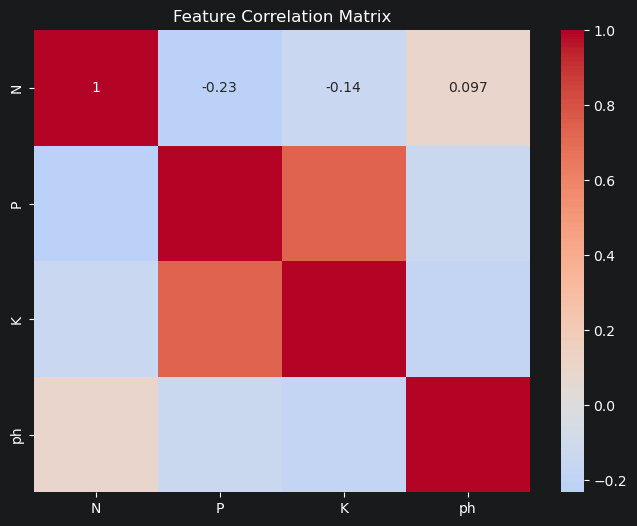

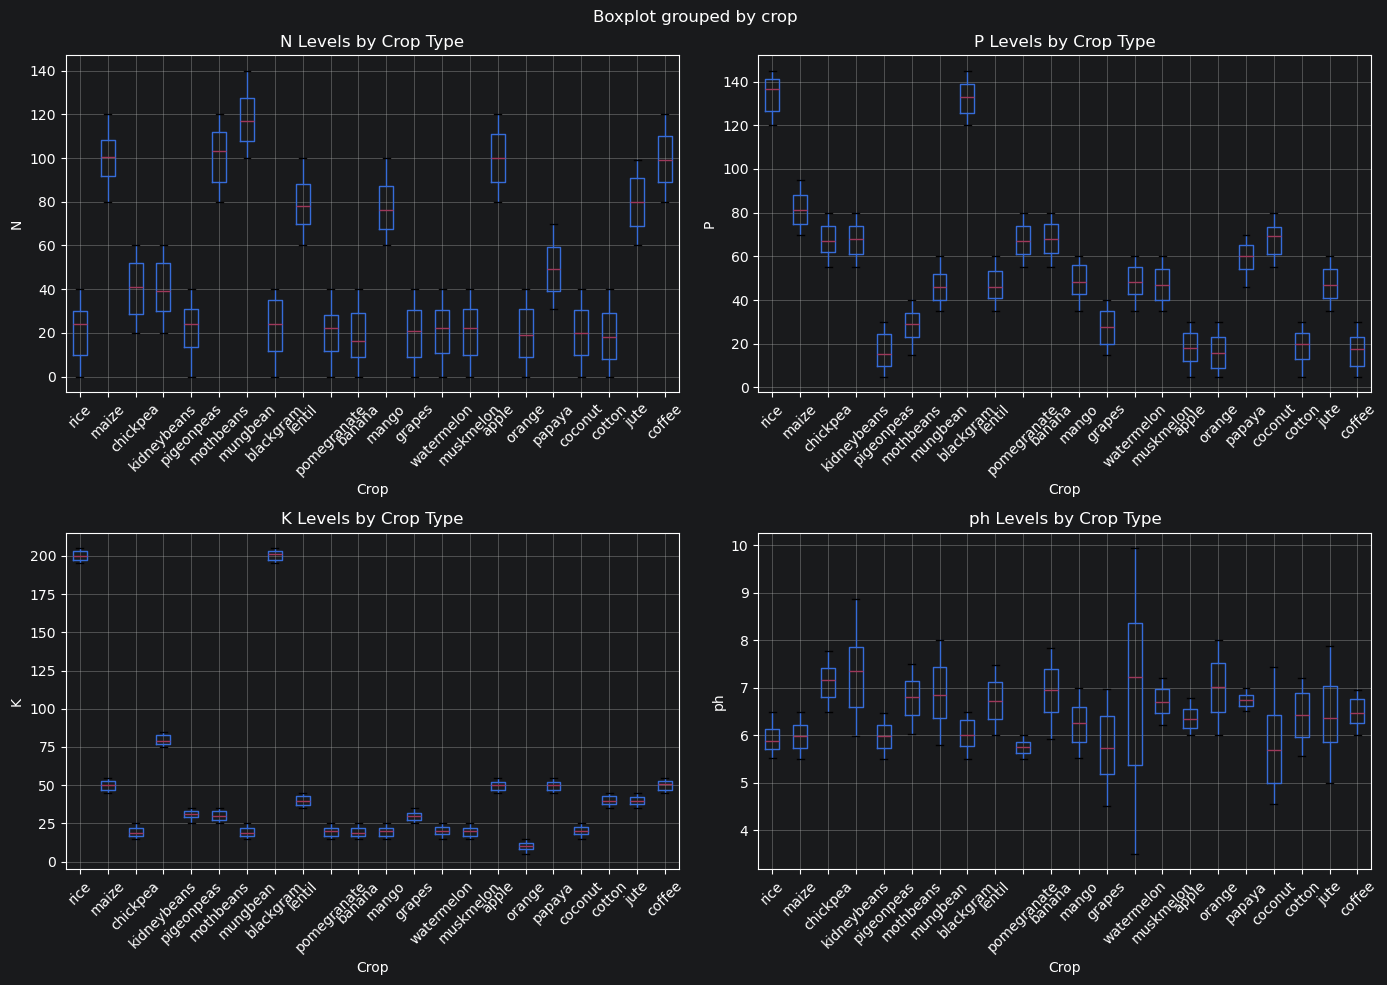

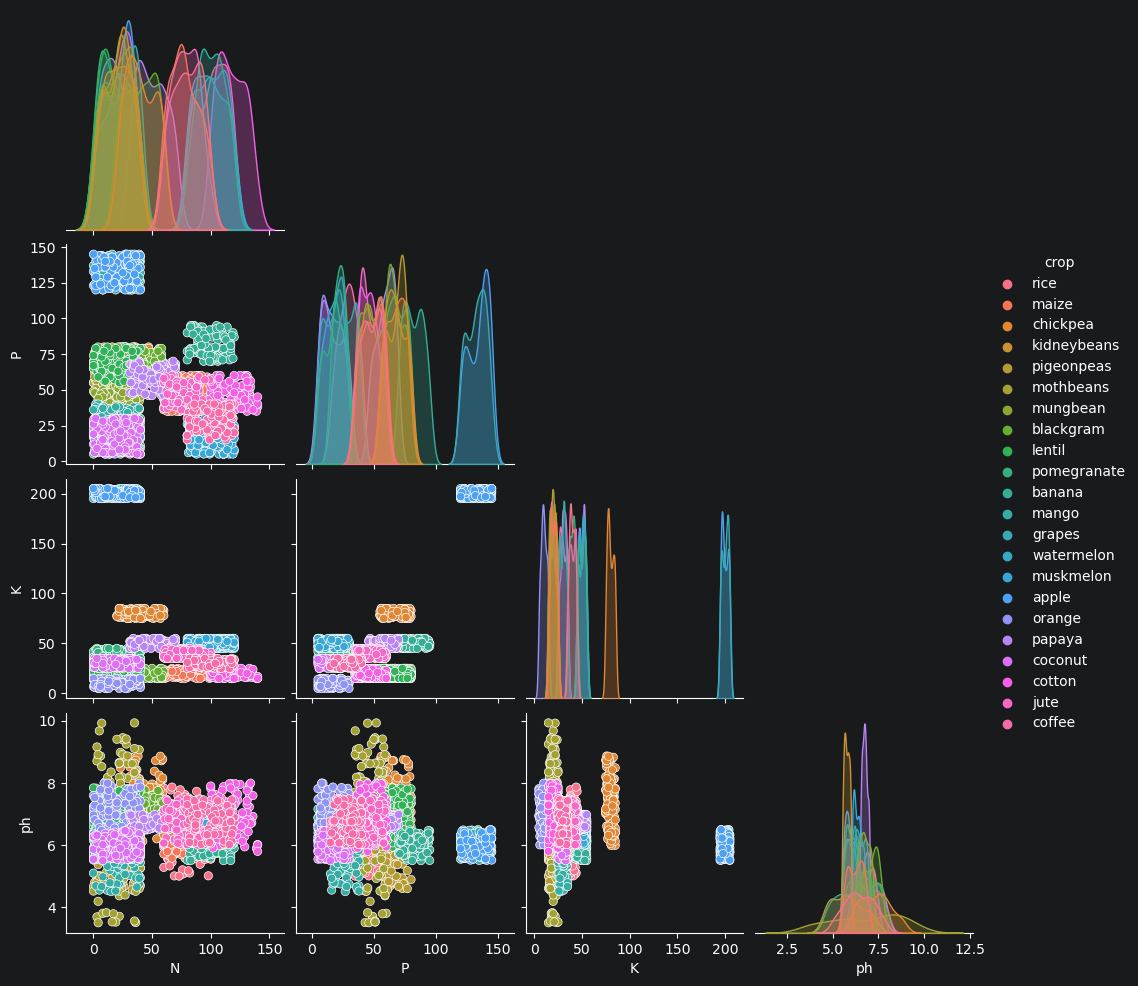

In [3]:
# Visualization modules
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class distribution
plt.figure(figsize=(10, 6))
crops['crop'].value_counts().plot(kind='bar')
plt.title('Crop Distribution in Dataset')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, feature in enumerate(['N', 'P', 'K', 'ph']):
    ax = axes[idx//2, idx%2]
    crops[feature].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(crops[['N', 'P', 'K', 'ph']].corr(),
            annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.savefig('../images/feature_correlation.png', bbox_inches='tight', dpi=300)
plt.show()

# 4. Boxplots by crop type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, feature in enumerate(['N', 'P', 'K', 'ph']):
    ax = axes[idx//2, idx%2]
    crops.boxplot(column=feature, by='crop', ax=ax)
    ax.set_title(f'{feature} Levels by Crop Type')
    ax.set_xlabel('Crop')
    ax.set_xticklabels(crops['crop'].unique(), rotation=45)
    ax.set_ylabel(feature)
plt.tight_layout()
plt.show()

# 5. Pairplot for relationships
sns.pairplot(crops, hue='crop', diag_kind='kde', corner=True)
plt.show()

                        Accuracy  F1 Score  Precision    Recall
Random Forest           0.798485  0.793966   0.794268  0.798485
Gradient Boosting       0.774242  0.771792   0.774046  0.774242
Decision Tree           0.768182  0.766135   0.766118  0.768182
Naive Bayes             0.765152  0.759910   0.766803  0.765152
K-Nearest Neighbors     0.739394  0.736385   0.748533  0.739394
Support Vector Machine  0.733333  0.725391   0.749376  0.733333
Logistic Regression     0.654545  0.650170   0.651375  0.654545


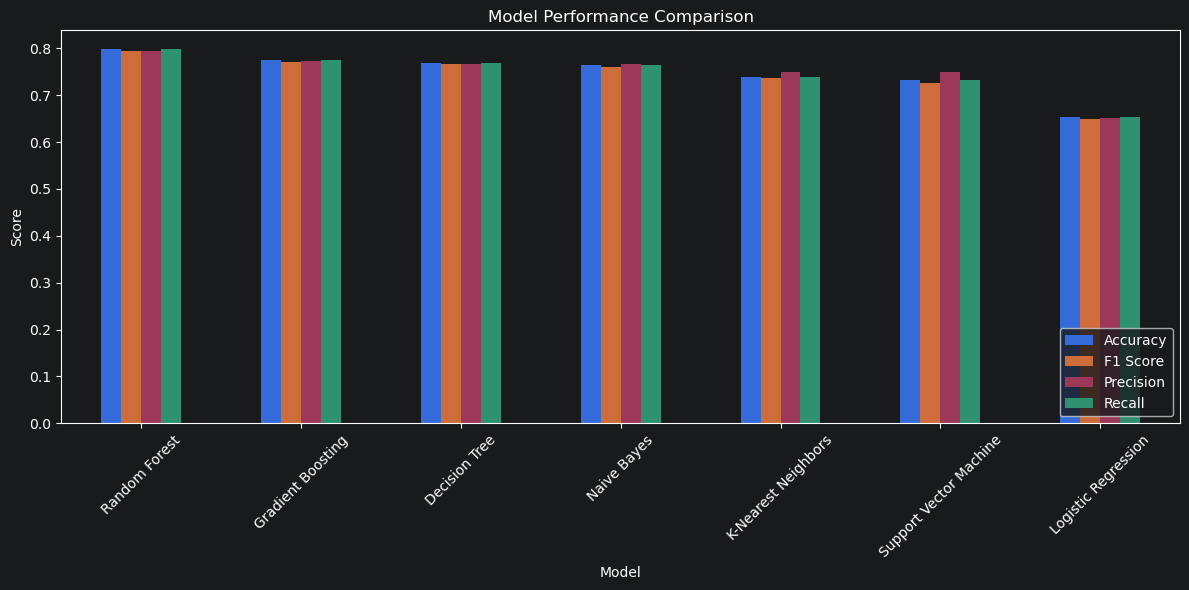

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# Split the data into feature and target sets
X = crops.drop("crop", axis=1)
y = crops["crop"]

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12, shuffle=True, stratify=y)

# Scale features (important for distance-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define multiple models
models = {
    'Logistic Regression': LogisticRegression(multi_class='multinomial', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Train and evaluate all models
results = {}
for name, model in models.items():
    # Use scaled data for distance-sensitive models
    if name in ['K-Nearest Neighbors', 'Support Vector Machine', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calculate multiple metrics
    results[name] = {
        'Accuracy': metrics.accuracy_score(y_test, y_pred),
        'F1 Score': metrics.f1_score(y_test, y_pred, average='weighted'),
        'Precision': metrics.precision_score(y_test, y_pred, average='weighted'),
        'Recall': metrics.recall_score(y_test, y_pred, average='weighted')
    }

# Display results
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
print(results_df)

# Visualize model comparison
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.legend(loc='lower right', )
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

In [5]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Cross-validation for best model
best_model = RandomForestClassifier(random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1 score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)
print(f"\nTuned model test F1 score: {metrics.f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")

Cross-validation F1 scores: [0.76326203 0.78779242 0.75987054 0.78354537 0.76739751]
Mean CV F1 score: 0.7724 (+/- 0.0112)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Best CV score: 0.7884

Tuned model test F1 score: 0.7865


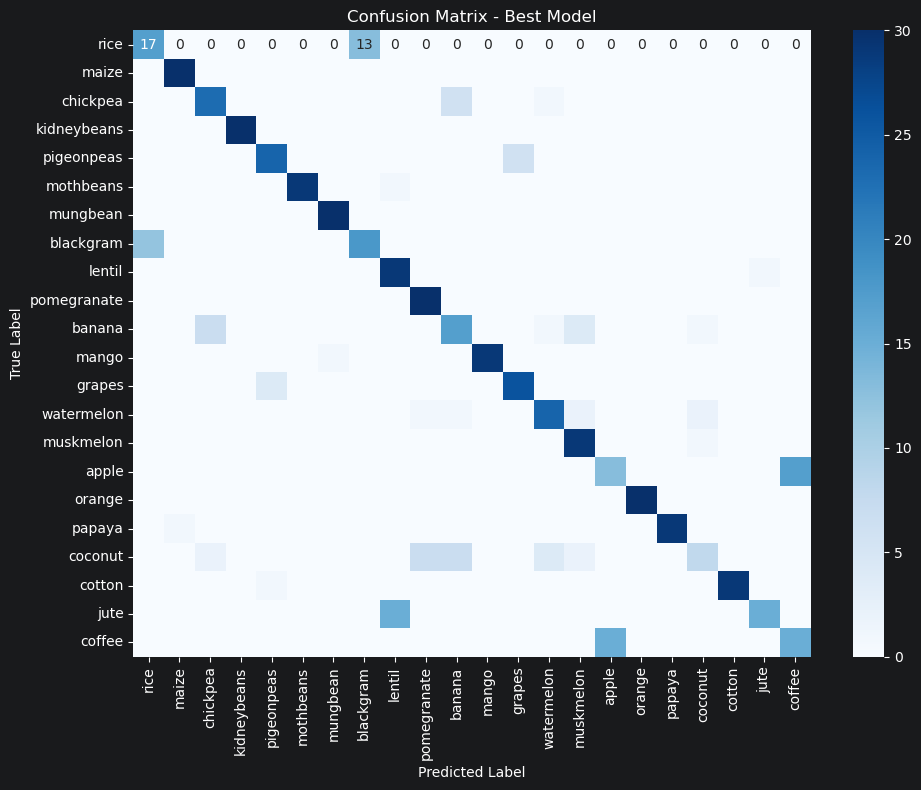


Detailed Classification Report:
              precision    recall  f1-score   support

       apple       0.59      0.57      0.58        30
      banana       0.97      1.00      0.98        30
   blackgram       0.72      0.77      0.74        30
    chickpea       1.00      1.00      1.00        30
     coconut       0.83      0.80      0.81        30
      coffee       1.00      0.97      0.98        30
      cotton       0.97      1.00      0.98        30
      grapes       0.58      0.60      0.59        30
        jute       0.64      0.97      0.77        30
 kidneybeans       0.79      1.00      0.88        30
      lentil       0.55      0.57      0.56        30
       maize       1.00      0.97      0.98        30
       mango       0.81      0.87      0.84        30
   mothbeans       0.80      0.80      0.80        30
    mungbean       0.78      0.97      0.87        30
   muskmelon       0.46      0.43      0.45        30
      orange       1.00      1.00      1.00     

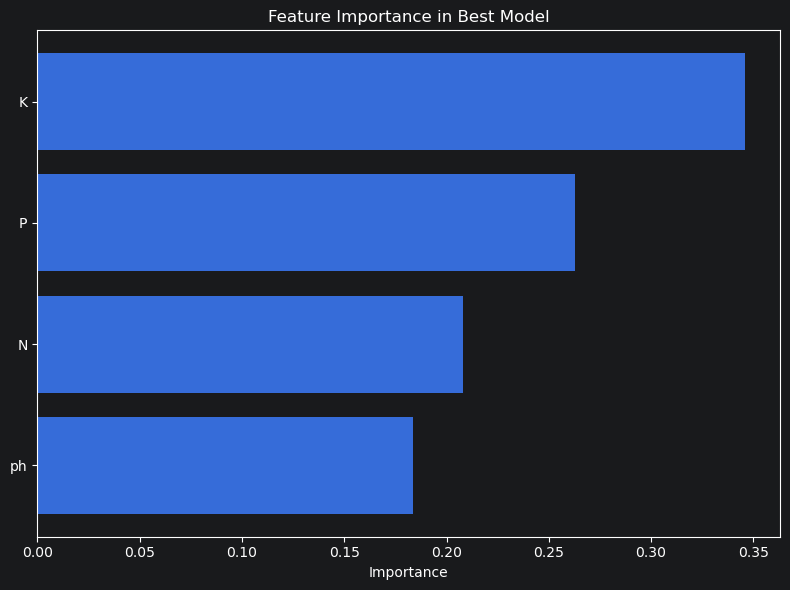


Feature Importance:
  Feature  Importance
2       K    0.345730
1       P    0.262801
0       N    0.207892
3      ph    0.183577


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

# Best model predictions
final_model = grid_search.best_estimator_
y_pred_final = final_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=crops['crop'].unique(),
            yticklabels=crops['crop'].unique())
plt.title('Confusion Matrix - Best Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_final))

# Feature importance (for tree-based models)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Best Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../images/feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

print("\nFeature Importance:")
print(feature_importance)


=== Feature: N ===
Logistic Regression: F1 = 0.1227
Random Forest: F1 = 0.1584
Decision Tree: F1 = 0.1598

=== Feature: P ===
Logistic Regression: F1 = 0.1751
Random Forest: F1 = 0.2090
Decision Tree: F1 = 0.1890

=== Feature: K ===
Logistic Regression: F1 = 0.2683
Random Forest: F1 = 0.2921
Decision Tree: F1 = 0.2943

=== Feature: ph ===
Logistic Regression: F1 = 0.0759
Random Forest: F1 = 0.1392
Decision Tree: F1 = 0.1392

=== Summary: F1 Scores by Feature and Model ===
    Logistic Regression  Random Forest  Decision Tree
N              0.122711       0.158363       0.159817
P              0.175094       0.209015       0.189039
K              0.268257       0.292084       0.294298
ph             0.075864       0.139216       0.139216


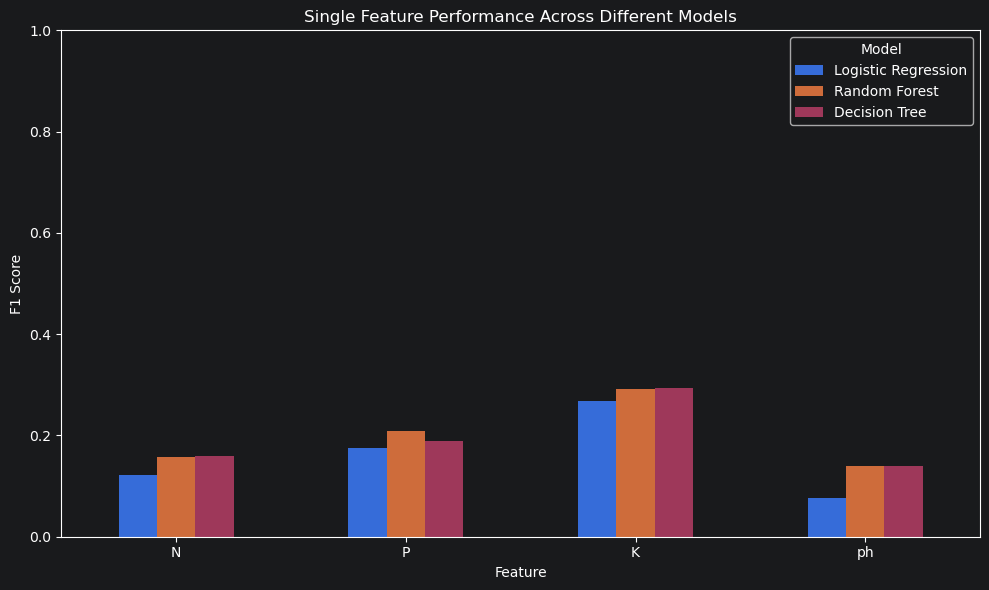


🏆 Best overall predictive feature: K
Average F1 Score: 0.2849


In [7]:
feature_performance = {}

# Test multiple model types
models_to_test = {
    'Logistic Regression': LogisticRegression(multi_class="multinomial", max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Evaluate each feature with each model
for feature in ["N", "P", "K", "ph"]:
    feature_performance[feature] = {}
    print(f"\n=== Feature: {feature} ===")

    for model_name, model in models_to_test.items():
        model.fit(X_train[[feature]], y_train)
        y_pred = model.predict(X_test[[feature]])
        f1 = metrics.f1_score(y_test, y_pred, average="weighted")
        feature_performance[feature][model_name] = f1
        print(f"{model_name}: F1 = {f1:.4f}")

# Convert to DataFrame for better visualization
feature_df = pd.DataFrame(feature_performance).T
print("\n=== Summary: F1 Scores by Feature and Model ===")
print(feature_df)

# Visualize the comparison
feature_df.plot(kind='bar', figsize=(10, 6))
plt.title('Single Feature Performance Across Different Models')
plt.xlabel('Feature')
plt.ylabel('F1 Score')
plt.legend(title='Model')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../images/single_feature_performance.png', bbox_inches='tight', dpi=300)
plt.show()

# Find best feature overall (average across models)
feature_df['Average'] = feature_df.mean(axis=1)
best_feature = feature_df['Average'].idxmax()
print(f"\n🏆 Best overall predictive feature: {best_feature}")
print(f"Average F1 Score: {feature_df.loc[best_feature, 'Average']:.4f}")

best_predictive_feature = {best_feature: feature_df.loc[best_feature, 'Average']}

In [8]:
# Cost-benefit analysis for feature selection
print("=== Recommendations for the Farmer ===\n")

# Get best performing full model from results_df
best_full_model = results_df['F1 Score'].idxmax()
best_full_f1 = results_df.loc[best_full_model, 'F1 Score']

# Get best single feature (based on average across models)
best_single_feature = feature_df['Average'].idxmax()
best_single_f1 = feature_df.loc[best_single_feature, 'Average']

# Train models with top 2 features for accurate comparison
top_2_features = feature_df['Average'].nlargest(2).index.tolist()
X_train_top2 = X_train[top_2_features]
X_test_top2 = X_test[top_2_features]

# Use best performing model from full analysis
two_feature_model = RandomForestClassifier(n_estimators=100, random_state=42)
two_feature_model.fit(X_train_top2, y_train)
y_pred_two_features = two_feature_model.predict(X_test_top2)
two_feature_f1 = metrics.f1_score(y_test, y_pred_two_features, average='weighted')

print("1. FULL SOIL ANALYSIS (All 4 metrics):")
print(f"   - Best Model: {best_full_model}")
print(f"   - Model Performance: {best_full_f1:.2%} F1 Score")
print(f"   - Best for: Maximum yield optimization")
print(f"   - Investment: Full soil testing (4 metrics)\n")

print(f"2. SINGLE METRIC ANALYSIS ({best_single_feature} only):")
print(f"   - Average Performance: {best_single_f1:.2%} F1 Score")
print(f"   - Best Model for {best_single_feature}: {feature_df.loc[best_single_feature].drop('Average').idxmax()}")
print(f"   - Best Single-Feature F1: {feature_df.loc[best_single_feature].drop('Average').max():.2%}")
print(f"   - Cost savings: ~75% (testing 1 vs 4 metrics)")
print(f"   - Performance loss: {(best_full_f1 - best_single_f1):.2%}")
print(f"   - Best for: Budget-constrained farms with limited testing budget\n")

print("3. TWO-METRIC ANALYSIS (Top 2 features):")
print(f"   - Recommended: Test {top_2_features[0]} and {top_2_features[1]}")
print(f"   - F1 Score: {two_feature_f1:.2%}")
print(f"   - {top_2_features[0]} average F1: {feature_df.loc[top_2_features[0], 'Average']:.2%}")
print(f"   - {top_2_features[1]} average F1: {feature_df.loc[top_2_features[1], 'Average']:.2%}")
print(f"   - Cost savings: ~50% (testing 2 vs 4 metrics)")
print(f"   - Best for: Balanced cost vs. performance trade-off\n")

# Feature ranking summary
print("=== Feature Importance Ranking (Single Feature Performance) ===")
feature_ranking = feature_df['Average'].sort_values(ascending=False)
for rank, (feature, score) in enumerate(feature_ranking.items(), 1):
    print(f"{rank}. {feature}: {score:.2%} average F1 score")

# Model-specific insights for best feature
print(f"\n=== Best Feature ({best_single_feature}) Performance by Model ===")
for model_name in feature_df.columns[:-1]:  # Exclude 'Average' column
    print(f"{model_name}: {feature_df.loc[best_single_feature, model_name]:.2%}")

# Crop-specific insights
print("\n=== Crop-Specific Accuracy (Best Full Model) ===")
report_dict = classification_report(y_test, y_pred_final, output_dict=True)
for crop in sorted(crops['crop'].unique()):
    if crop in report_dict:
        f1 = report_dict[crop]['f1-score']
        support = report_dict[crop]['support']
        print(f"{crop}: {f1:.2%} F1-score (n={int(support)} samples)")

# Summary recommendation table
print("\n=== Decision Matrix: Cost vs Performance ===")
decision_matrix = pd.DataFrame({
    'Strategy': ['Full Analysis (4 metrics)',
                 f'Two Metrics ({top_2_features[0]}, {top_2_features[1]})',
                 f'Single Metric ({best_single_feature})'],
    'Relative Cost': ['100%', '50%', '25%'],
    'Expected F1 Score': [f"{best_full_f1:.2%}",
                          f"{two_feature_f1:.2%}",
                          f"{best_single_f1:.2%}"],
    'Recommended For': ['Large commercial farms',
                        'Medium-sized operations',
                        'Small or budget-limited farms']
})
print(decision_matrix.to_string(index=False))
print("\n* Estimate based on top 2 features; actual training recommended for precise value")

=== Recommendations for the Farmer ===

1. FULL SOIL ANALYSIS (All 4 metrics):
   - Best Model: Random Forest
   - Model Performance: 79.40% F1 Score
   - Best for: Maximum yield optimization
   - Investment: Full soil testing (4 metrics)

2. SINGLE METRIC ANALYSIS (K only):
   - Average Performance: 28.49% F1 Score
   - Best Model for K: Decision Tree
   - Best Single-Feature F1: 29.43%
   - Cost savings: ~75% (testing 1 vs 4 metrics)
   - Performance loss: 50.91%
   - Best for: Budget-constrained farms with limited testing budget

3. TWO-METRIC ANALYSIS (Top 2 features):
   - Recommended: Test K and P
   - F1 Score: 48.47%
   - K average F1: 28.49%
   - P average F1: 19.10%
   - Cost savings: ~50% (testing 2 vs 4 metrics)
   - Best for: Balanced cost vs. performance trade-off

=== Feature Importance Ranking (Single Feature Performance) ===
1. K: 28.49% average F1 score
2. P: 19.10% average F1 score
3. N: 14.70% average F1 score
4. ph: 11.81% average F1 score

=== Best Feature (K) Per